<h1 style="
    text-align:center;
    font-size:42px;
    color:white;
    background-color:#E50914;
    padding:20px;
    border-radius:12px;
    letter-spacing:2px;">
🎬 Netflix Data Analysis Project
</h1>

###  Structural and Semantic Understanding of the Dataset  

###  Comprehensive Step-by-Step Advanced EDA Workflow

###  Dataset: _netflix_movies_detailed_up_to_2025.csv_

## STEP 1 :-  Load importat librararies and load dataset 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/hasya/OneDrive/Desktop/Synent Technologies/TASK1/data/netflix_movies_detailed_up_to_2025.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


## STEP 2 :- Basic Understanding of Data

In [3]:
df.shape
df.columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [4]:
df.isnull().sum()

show_id             0
type                0
title               0
director          132
cast              204
country           466
date_added          0
release_year        0
rating              0
duration        16000
genres            107
language            0
description       132
popularity          0
vote_count          0
vote_average        0
budget              0
revenue             0
dtype: int64

## STEP 3 :- Data cleaning 

3.1 Handle Missing Values

In [ ]:

df = df.drop(columns=['duration'], errors='ignore')

df['country'] = df['country'].fillna("Unknown")
df['genres'] = df['genres'].fillna("Unknown")

3.2 Convert Date Column

In [ ]:

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


3.3 Remove Duplicates

In [7]:
df = df.drop_duplicates(subset=['title'])

3.4  Split Genres

In [ ]:
df['genres'] = df['genres'].str.split(',')

df = df.explode('genres')

df['genres'] = df['genres'].str.strip()

## STEP 4: Feature Engineering

4.1 Create Decade Column

In [9]:
df['decade'] = (df['release_year'] // 10) * 10
df['decade'] = df['decade'].astype(str) + 's'

4.2 Popularity Tier

In [10]:
median_popularity = df['popularity'].median()

df['popularity_tier'] = df['popularity'].apply(
    lambda x: 'High' if x >= median_popularity else 'Low'
)

4.3 Rating Category

In [11]:
def rating_category(x):
    if x < 5:
        return 'Flop'
    elif x <= 7.5:
        return 'Average'
    else:
        return 'Masterpiece'

df['rating_category'] = df['vote_average'].apply(rating_category)

4.4 Content Age   &  Is Recent Content (Last 5 Years)

In [12]:
df['content_age'] = 2025 - df['release_year']
df['is_recent'] = df['release_year'].apply(lambda x: 'Recent' if x >= 2020 else 'Old')

4.5 Title Length (Number of Words)

In [13]:
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))

4.6 Cast Count (Number of Actors)

In [14]:
df['cast_count'] = df['cast'].fillna('').apply(lambda x: 0 if x == '' else len(x.split(',')))

## STEP 5 :- Summary Statistics

5.1 Summary Statistics

In [ ]:
df.describe()

df.describe(include='object')

print("Average Rating:", df['vote_average'].mean())

print(df['genres'].value_counts().head(10))

print(df['country'].value_counts().head(10))

Average Rating: 6.094805841782761
genres
Drama        6655
Comedy       4444
Thriller     3550
Action       3132
Romance      2507
Horror       2319
Adventure    1722
Crime        1671
Animation    1567
Family       1452
Name: count, dtype: int64
country
United States of America                    12678
Japan                                        2568
South Korea                                  1540
United Kingdom                               1243
France                                       1096
India                                        1029
United Kingdom, United States of America      963
Canada, United States of America              875
Canada                                        818
Unknown                                       762
Name: count, dtype: int64


5.2 Content Density per Year

In [16]:
content_density = df.groupby('release_year').size()
print(content_density)

release_year
2010    2466
2011    2372
2012    2340
2013    2231
2014    2240
2015    2373
2016    2359
2017    2367
2018    2357
2019    2291
2020    2159
2021    2312
2022    2331
2023    2272
2024    2136
2025    1787
dtype: int64


## STEP 6 :- Univariate Analysis — Single Variable Analysis

6.1 Rating Distribution

In [17]:
df["vote_average"]

0        6.38
0        6.38
0        6.38
0        6.38
0        6.38
         ... 
15996    0.00
15997    1.00
15998    0.00
15999    0.00
15999    0.00
Name: vote_average, Length: 36393, dtype: float64

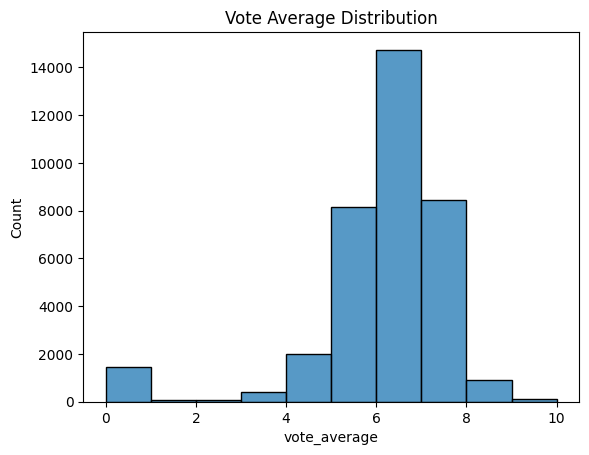

In [18]:
plt.figure()
sns.histplot(df['vote_average'], bins=10)
plt.title("Vote Average Distribution")
plt.show()

6.2 Top Genres

In [19]:
df['genres']

0           Comedy
0        Adventure
0          Fantasy
0        Animation
0           Family
           ...    
15996        Drama
15997       Horror
15998      Unknown
15999       Comedy
15999       Horror
Name: genres, Length: 36393, dtype: object

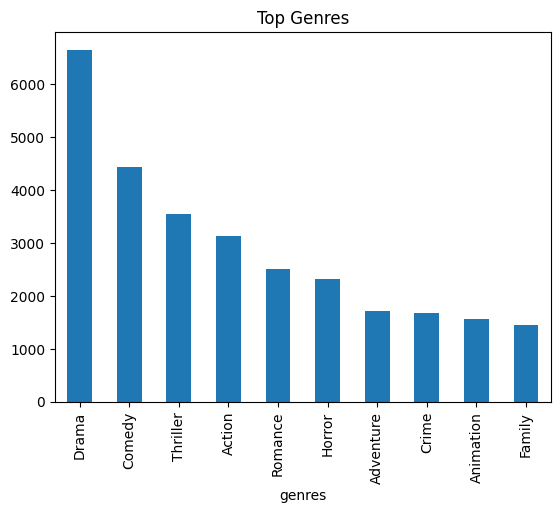

In [20]:
top_genres = df['genres'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title("Top Genres")
plt.show()

6.3 Release Year Distribution

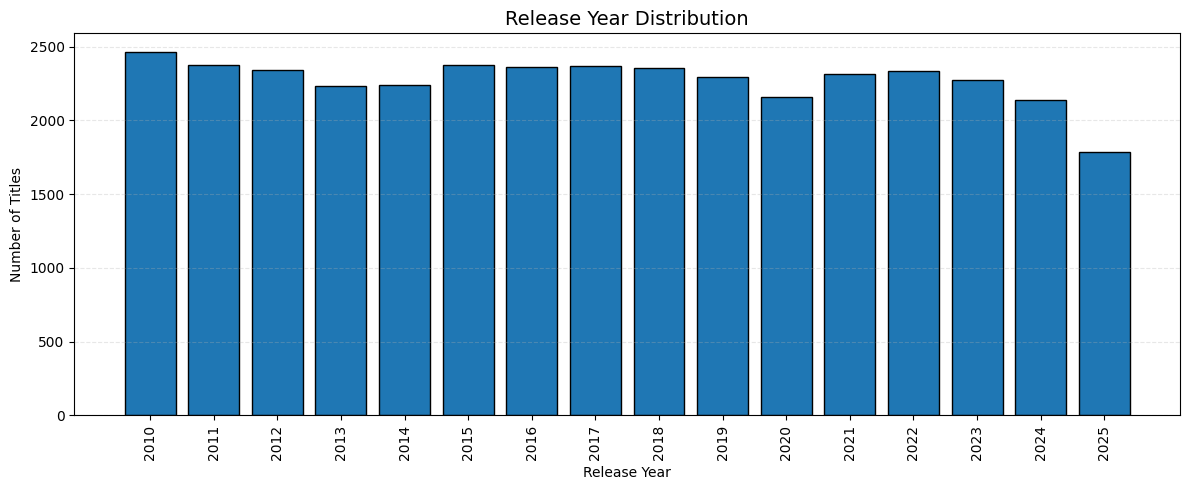

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.bar(
    year_counts.index,
    year_counts.values,
    edgecolor='black'
)

plt.title("Release Year Distribution", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.xticks(year_counts.index, rotation=90)  # show every year
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## STEP 7 :- Outlier Detection

In [ ]:
cult_classics = df[(df['popularity'] > df['popularity'].quantile(0.90)) &(df['vote_average'] < 5)]

print(cult_classics[['title', 'popularity', 'vote_average']].head())

hidden_gems = df[(df['vote_average'] > 8.5) &(df['vote_count'] < df['vote_count'].median())]

print(hidden_gems[['title', 'vote_average', 'vote_count']].head())

                                      title  popularity  vote_average
30                       The Last Airbender      42.597           4.6
30                       The Last Airbender      42.597           4.6
30                       The Last Airbender      42.597           4.6
1035  The Human Centipede 2 (Full Sequence)      38.243           4.8
1035  The Human Centipede 2 (Full Sequence)      38.243           4.8
                                                  title  vote_average  \
799                                       Fumiko's Feet           9.0   
862                   Inácio Garapa, Um Matuto Sonhador          10.0   
862                   Inácio Garapa, Um Matuto Sonhador          10.0   
862                   Inácio Garapa, Um Matuto Sonhador          10.0   
1496  Lady Gaga Presents: The Monster Ball Tour at M...           8.6   

      vote_count  
799            1  
862            1  
862            1  
862            1  
1496          99  


## STEP 8 :- Correlation Analysis

8.1 Relationship Between Numerical Features

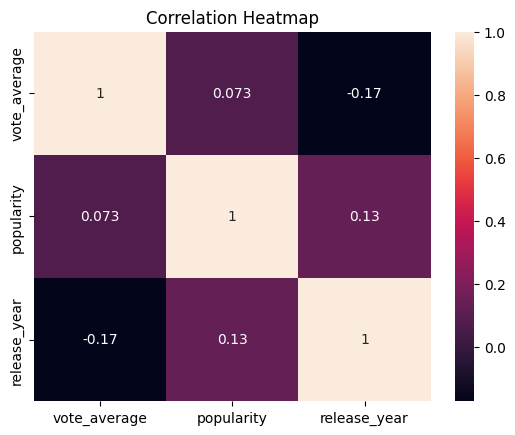

In [23]:
plt.figure()
sns.heatmap(df[['vote_average', 'popularity', 'release_year']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

8.2 Encoded Genre Count + Correlation Heatmap

In [24]:
df['genre_count'] = df['genres'].apply(
    lambda x: len(str(x).split('|'))
)

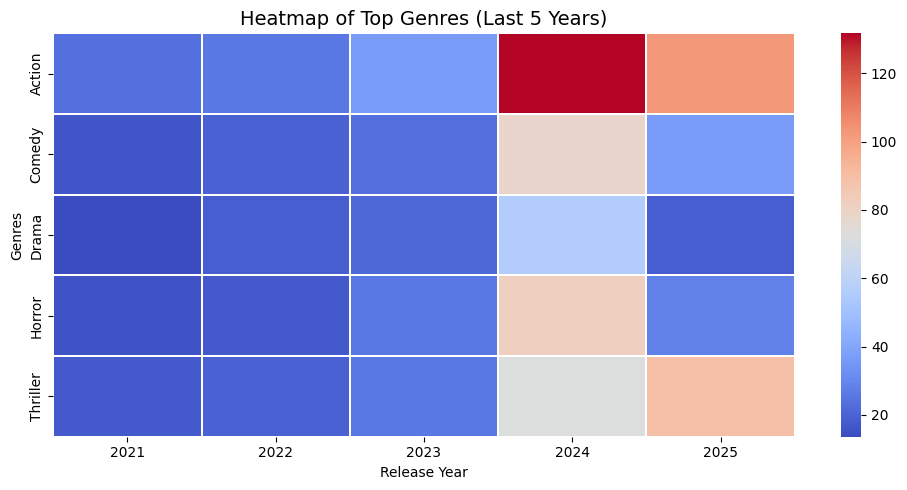

In [ ]:
df['genres'] = df['genres'].fillna('Unknown')

last_5_years = sorted(df['release_year'].dropna().unique())[-5:]

df_recent = df[df['release_year'].isin(last_5_years)]

top_genres = df_recent['genres'].value_counts().head(5).index
filtered_df = df_recent[df_recent['genres'].isin(top_genres)]

pivot_data = filtered_df.pivot_table(index='genres', columns='release_year',values='popularity', aggfunc='mean')

plt.figure(figsize=(10,5))

sns.heatmap(pivot_data,cmap='coolwarm',linewidths=0.3)

plt.title("Heatmap of Top Genres (Last 5 Years)", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Genres")

plt.tight_layout()
plt.show()

## STEP 9 :- Bivariate Analysis — Relationship Between Two Variables

9.1 :- Genre vs Rating

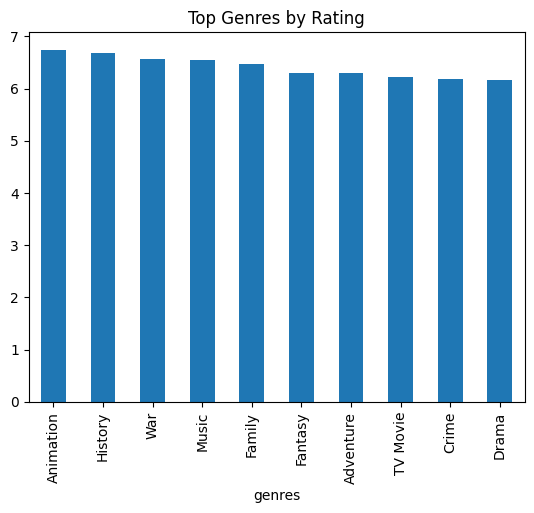

In [26]:
genre_rating = df.groupby('genres')['vote_average'].mean().sort_values(ascending=False).head(10)

plt.figure()
genre_rating.plot(kind='bar')
plt.title("Top Genres by Rating")
plt.show()

9.2 Country vs Genre 

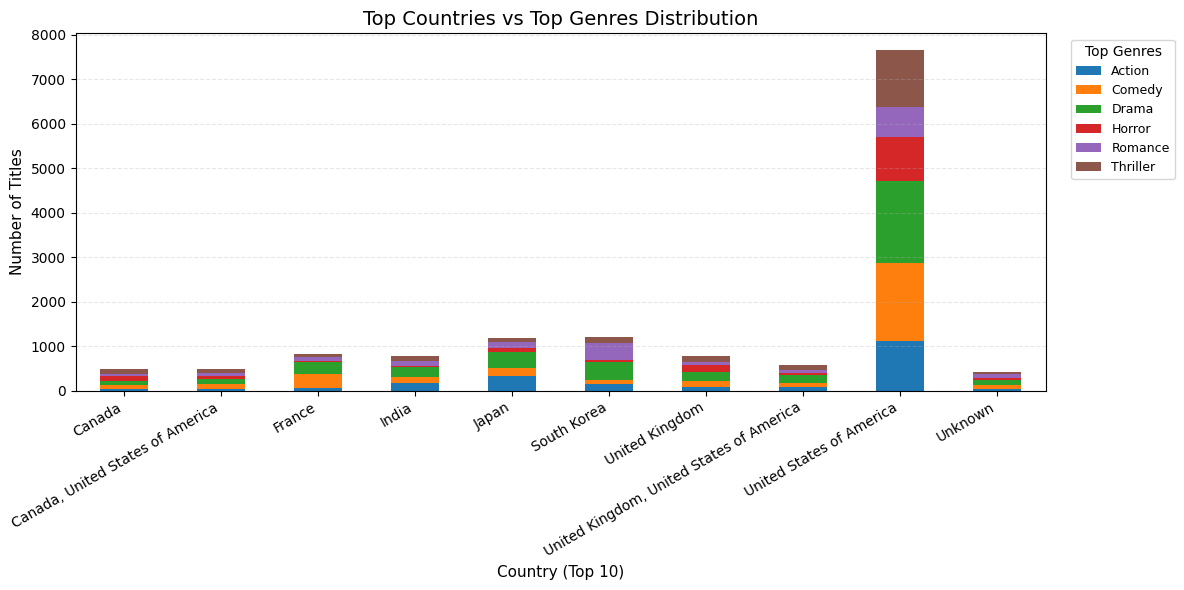

In [ ]:
top_countries = df['country'].value_counts().head(10).index
filtered_df = df[df['country'].isin(top_countries)]

top_genres = df['genres'].value_counts().head(6).index
filtered_df = filtered_df[filtered_df['genres'].isin(top_genres)]

country_genre = filtered_df.groupby(['country', 'genres']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
country_genre.plot(kind='bar', stacked=True, ax=plt.gca())

plt.title("Top Countries vs Top Genres Distribution", fontsize=14)
plt.xlabel("Country (Top 10)", fontsize=11)
plt.ylabel("Number of Titles", fontsize=11)

plt.xticks(rotation=30, ha='right')

plt.legend(
    title="Top Genres",
    bbox_to_anchor=(1.02,1),
    loc='upper left',
    fontsize=9
)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

9.3 Country vs Popularity

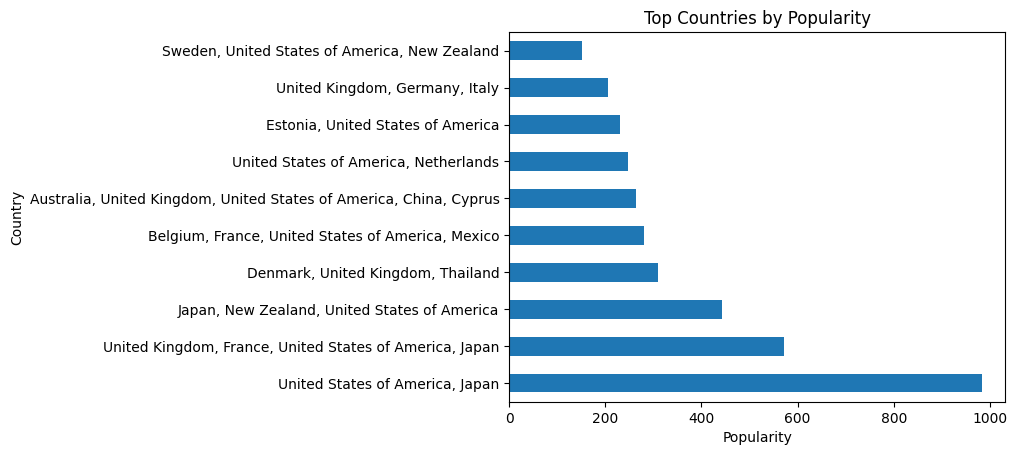

In [ ]:
country_pop = df.groupby('country')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure()
country_pop.plot(kind='barh')  
plt.title("Top Countries by Popularity")
plt.xlabel("Popularity")   
plt.ylabel("Country")     
plt.show()

9.4 Release Year vs Popularity

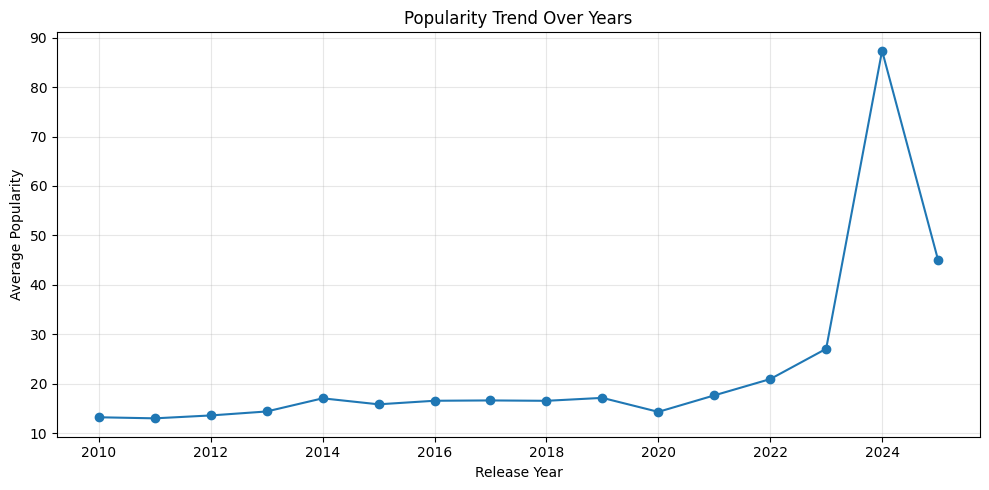

In [29]:
year_pop = df.groupby('release_year')['popularity'].mean()

plt.figure(figsize=(10,5))
plt.plot(year_pop.index, year_pop.values, marker='o')

plt.title("Popularity Trend Over Years")
plt.xlabel("Release Year")
plt.ylabel("Average Popularity")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## STEP 10 :- Trend Analysis — Time-Based Analysis


10.1 Content Growth Over Time

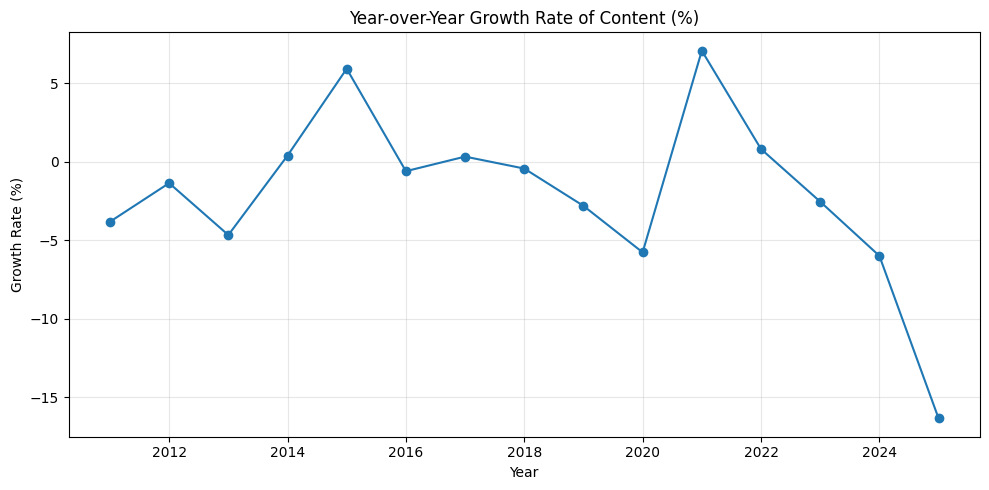

In [ ]:
year_count = df['release_year'].value_counts().sort_index()

growth_rate = year_count.pct_change() * 100

plt.figure(figsize=(10,5))
plt.plot(growth_rate.index, growth_rate.values, marker='o')

plt.title("Year-over-Year Growth Rate of Content (%)")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

10.2 Genre Evolution

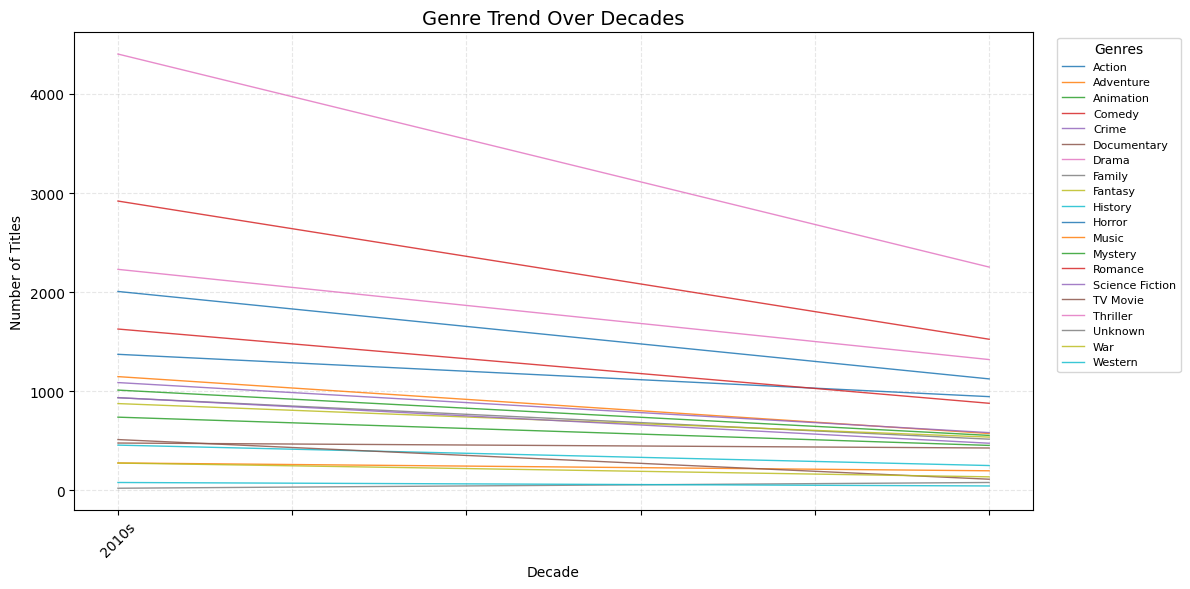

In [43]:
genre_trend = df.groupby(['decade', 'genres']).size().unstack().fillna(0)

plt.figure(figsize=(12,6))

genre_trend.plot(
    ax=plt.gca(),
    linewidth=1,
    alpha=0.85
)

plt.title("Genre Trend Over Decades", fontsize=14)
plt.xlabel("Decade")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend(
    title="Genres",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8,
    ncol=1
)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

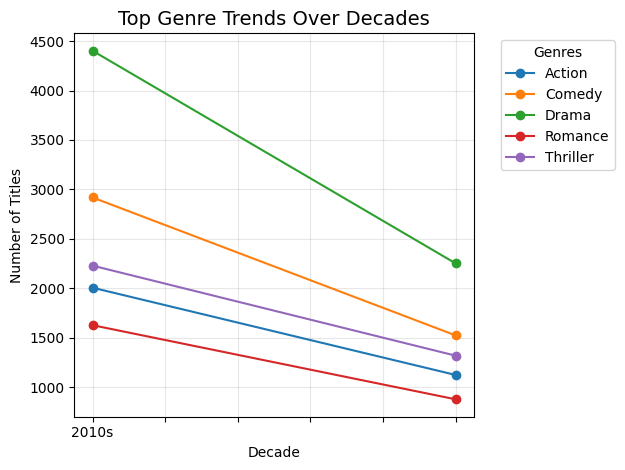

In [ ]:
top_genres = df['genres'].value_counts().head(5).index

filter_df = df[df['genres'].isin(top_genres)]

genre_trend = filter_df.groupby(['decade', 'genres']).size().unstack().fillna(0)

plt.figure(figsize=(12,6))
genre_trend.plot(marker='o')

plt.title("Top Genre Trends Over Decades", fontsize=14)
plt.xlabel("Decade")
plt.ylabel("Number of Titles")
plt.legend(title="Genres", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 11: Advanced Analysis

11.1 Director Analysis

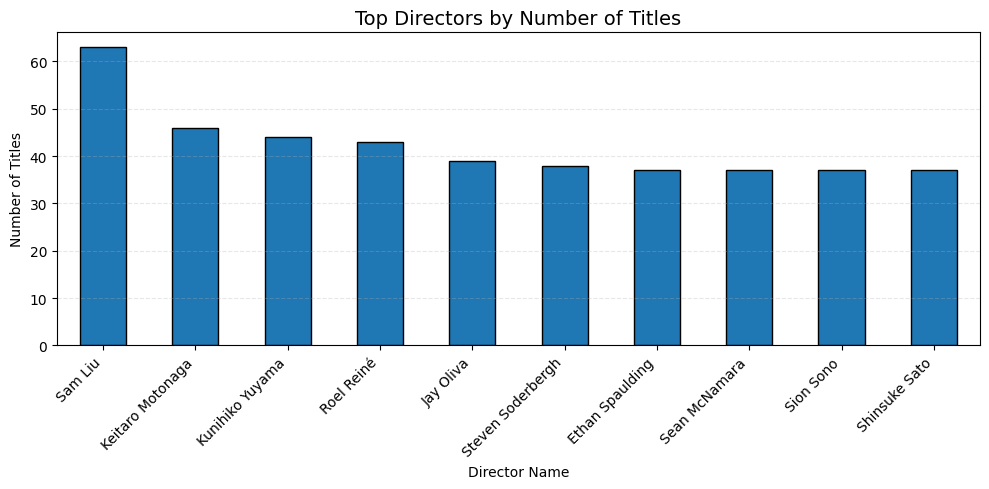

In [ ]:
df['director'] = df['director'].fillna('Unknown')

directors = df['director'][(df['director'] != 'Unknown') & (df['director'].str.strip() != '')]

top_directors = directors.value_counts().head(10)

plt.figure(figsize=(10,5))
top_directors.plot(kind='bar', edgecolor='black')

plt.title("Top Directors by Number of Titles", fontsize=14)
plt.xlabel("Director Name")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

11.2 Actor Popularity Score

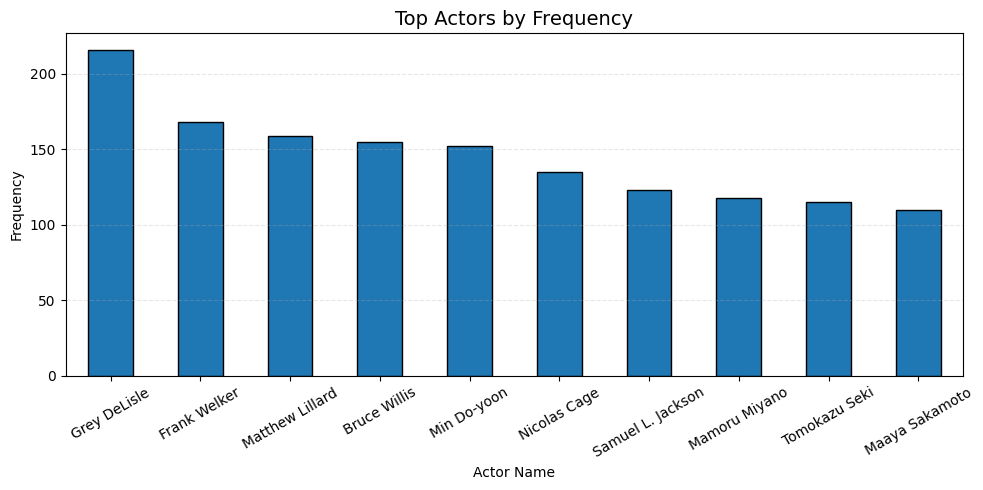

In [ ]:
df['cast'] = df['cast'].fillna('')

actors = df['cast'].str.split(',').explode().str.strip()

actors = actors[actors != '']

actor_popularity = actors.value_counts().head(10)

plt.figure(figsize=(10,5))
actor_popularity.plot(kind='bar', edgecolor='black')

plt.title("Top Actors by Frequency", fontsize=14)
plt.xlabel("Actor Name")
plt.ylabel("Frequency")

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

11.3 Regional Quality

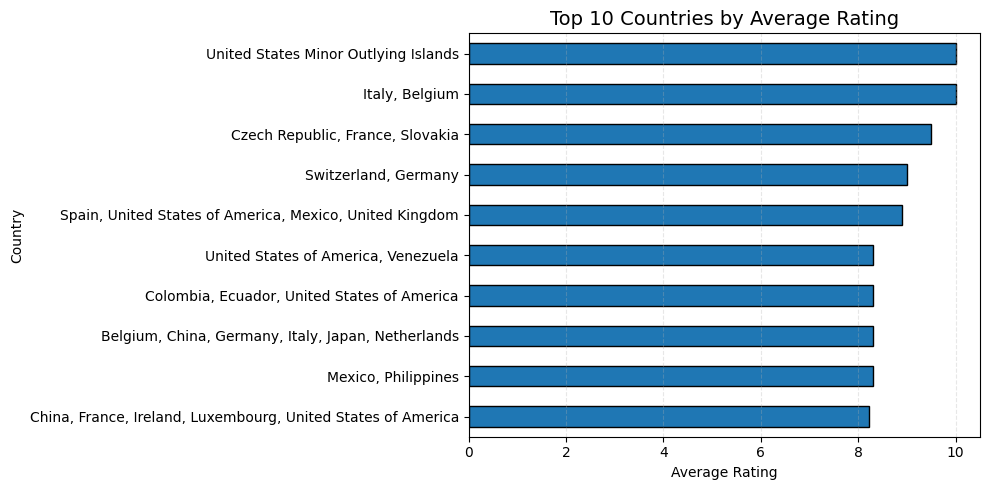

In [69]:
region_rating = df.groupby('country')['vote_average'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

region_rating.sort_values().plot(
    kind='barh',
    edgecolor='black'
)

plt.title("Top 10 Countries by Average Rating", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Country")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## EDA Final Insights

###  Key Insights
1. Content production shows a significant increase after 2015, reflecting rapid platform expansion.  
2. Drama emerges as the most dominant genre across the dataset.  
3. There is a weak correlation between popularity and rating, indicating different influencing factors.  
4. The USA leads in content production, followed by other major regions.  

###  Advanced Analysis Summary
Advanced feature engineering was performed by deriving temporal, categorical, and structural attributes such as content age, cast count, genre density, and multi-dimensional combinations. This enhanced the analytical depth and enabled the discovery of hidden patterns within the dataset.

###  Conclusion
The exploratory data analysis reveals that Netflix's content strategy focuses on rapid expansion, diverse genre offerings, and global reach. The insights derived can support data-driven decision-making for content recommendation, production strategy, and audience targeting.